# 04. Baseline SER - MFCC + Logistic Regression / SVM / Random Forest

Notebook này train các baseline truyền thống cho Speech Emotion Recognition (SER) dựa trên feature vector đã trích xuất ở bước Data Processing.

Mục tiêu chính:

- Tạo mốc so sánh trước khi train CNN/log-Mel.
- Train và so sánh Logistic Regression, SVM và Random Forest.
- Báo cáo accuracy, macro-F1, classification report, confusion matrix.
- Phân tích performance theo từng dataset: CREMA-D, RAVDESS, TESS.
- Lưu model, metric, hình ảnh và file đóng gói để tải về.

Input bắt buộc:

- `metadata.csv`
- `baseline_features.npz`
- `processing_config.json` nếu có

Notebook tự tìm các file này trong Kaggle input/working hoặc trong workspace local.

## 1. Cài đặt và import thư viện

Cell dưới kiểm tra các thư viện cần thiết. Kaggle thường đã có `numpy`, `pandas`, `sklearn`, `matplotlib`, `seaborn`, `joblib`. Nếu thiếu thư viện nhẹ, notebook sẽ cài bổ sung.

In [1]:
import sys
import subprocess
import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing = [pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import json
import time
import shutil
import subprocess
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries ready.")

Libraries ready.


## 2. Tự tìm processed dataset/artifact

Notebook ưu tiên tìm artifact theo thứ tự:

1. Kaggle working: `/kaggle/working/**/ser_processed`
2. Kaggle input: `/kaggle/input/**/ser_processed`
3. Kaggle input root có trực tiếp `metadata.csv` và `baseline_features.npz`
4. Workspace local hiện tại, ví dụ `01&02_Data_and_DataProcessing/ser_processed`

Nếu Kaggle dataset của bạn chứa folder `ser_processed`, không cần sửa path bằng tay.

In [2]:
def looks_like_processed_dir(path: Path) -> bool:
    return (path / "metadata.csv").exists() and (path / "baseline_features.npz").exists()


def find_processed_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    explicit_candidates = [
        cwd / "ser_processed",
        cwd / "Speech_Project" / "ser_processed",
        cwd / "01&02_Data_and_DataProcessing" / "ser_processed",
        cwd.parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        cwd.parent / "Data_and_DataProcessing" / "ser_processed",
        Path("/kaggle/working/Speech_Project/ser_processed"),
        Path("/kaggle/working/ser_processed"),
    ]
    candidates.extend(explicit_candidates)

    search_roots = [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        cwd,
        cwd.parent,
    ]

    for root in search_roots:
        if root.exists():
            candidates.extend(root.glob("**/ser_processed"))
            candidates.extend(p.parent for p in root.glob("**/baseline_features.npz"))

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except Exception:
            resolved = candidate
        if str(resolved) not in seen:
            seen.add(str(resolved))
            unique_candidates.append(resolved)

    valid = [p for p in unique_candidates if looks_like_processed_dir(p)]
    if not valid:
        checked = "\n".join(str(p) for p in unique_candidates[:40])
        raise FileNotFoundError(
            "Không tìm thấy processed artifact gồm metadata.csv và baseline_features.npz. "
            "Hãy chắc chắn Kaggle input hoặc local workspace có folder ser_processed.\n"
            f"Đã kiểm tra một số path:\n{checked}"
        )

    # Prefer writable Kaggle/local working outputs over read-only input only when artifacts exist there.
    valid = sorted(valid, key=lambda p: ("/kaggle/input" in str(p), len(str(p))))
    return valid[0]


PROCESSED_DIR = find_processed_dir()

if Path("/kaggle/working").exists():
    PROJECT_ROOT = Path("/kaggle/working/Speech_Project")
else:
    PROJECT_ROOT = Path.cwd().resolve()

OUTPUT_DIR = PROJECT_ROOT / "04_train_baseline_mfcc" / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
PRED_DIR = OUTPUT_DIR / "predictions"

for directory in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR, PRED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROCESSED_DIR: D:\UTE\Speech Programming\Speech Project\01&02_Data_and_DataProcessing\ser_processed
OUTPUT_DIR: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs


## 3. Load metadata, feature và config

Feature dùng trong notebook này là `X_scaled` từ `baseline_features.npz`. Scaler đã được fit trên train split ở notebook Data Processing, nên tránh được data leakage.

In [3]:
METADATA_PATH = PROCESSED_DIR / "metadata.csv"
FEATURE_PATH = PROCESSED_DIR / "baseline_features.npz"
CONFIG_PATH = PROCESSED_DIR / "processing_config.json"

metadata = pd.read_csv(METADATA_PATH)
features = np.load(FEATURE_PATH, allow_pickle=True)

if CONFIG_PATH.exists():
    config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
else:
    config = {}

print("Metadata shape:", metadata.shape)
print("Feature arrays:", features.files)
print("Config:", json.dumps(config, indent=2, ensure_ascii=False))

display(metadata.head())

Metadata shape: (10897, 15)
Feature arrays: ['X', 'X_scaled', 'y', 'sample_id', 'split', 'scaler_mean', 'scaler_scale']
Config: {
  "target_sample_rate": 16000,
  "target_duration_seconds": 4.0,
  "common_emotions": [
    "neutral",
    "happy",
    "sad",
    "angry",
    "fear",
    "disgust"
  ],
  "split_strategy": "GroupShuffleSplit by speaker_id",
  "random_state": 42,
  "baseline_feature_dimension": 248
}


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train


## 4. Kiểm tra chất lượng input

Các kiểm tra bắt buộc:

- Số dòng metadata khớp số vector feature.
- Không duplicate `sample_id`.
- Không duplicate `dataset + source_filename` nếu có cột `source_filename`.
- Split có đủ train/validation/test.
- Không overlap speaker giữa các split.

In [4]:
X = features["X_scaled"].astype(np.float32)
y = features["y"].astype(str)
feature_sample_ids = features["sample_id"].astype(str)
feature_splits = features["split"].astype(str)

assert len(metadata) == len(X) == len(y) == len(feature_sample_ids), "Metadata và feature không khớp số dòng."
assert metadata["sample_id"].astype(str).tolist() == feature_sample_ids.tolist(), "sample_id metadata và npz không cùng thứ tự."
assert metadata["split"].astype(str).tolist() == feature_splits.tolist(), "split metadata và npz không cùng thứ tự."
assert metadata["sample_id"].duplicated().sum() == 0, "sample_id bị duplicate."

if "source_filename" in metadata.columns:
    duplicate_source = metadata.duplicated(["dataset", "source_filename"]).sum()
else:
    duplicate_source = metadata.assign(
        source_filename=metadata["filepath"].map(lambda x: Path(str(x)).name.lower())
    ).duplicated(["dataset", "source_filename"]).sum()

print("Duplicate dataset + filename:", duplicate_source)
print("Split counts:")
display(metadata["split"].value_counts().rename_axis("split").reset_index(name="samples"))

print("Dataset x split:")
display(pd.crosstab(metadata["dataset"], metadata["split"]))

print("Emotion x split:")
display(pd.crosstab(metadata["emotion"], metadata["split"]))

speaker_overlap = {}
for s1, s2 in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    a = set(metadata.loc[metadata["split"] == s1, "speaker_id"].astype(str))
    b = set(metadata.loc[metadata["split"] == s2, "speaker_id"].astype(str))
    speaker_overlap[f"{s1}-{s2}"] = len(a & b)

print("Speaker overlap:", speaker_overlap)
assert all(v == 0 for v in speaker_overlap.values()), "Có speaker overlap giữa các split."
assert duplicate_source == 0, "Còn duplicate dataset + filename."

Duplicate dataset + filename: 0
Split counts:


,split,samples
0,train,7062
1,test,2890
2,validation,945


Dataset x split:


split,test,train,validation
dataset,,,
CREMA-D,1470,5070,901
RAVDESS,220,792,44
TESS,1200,1200,0


Emotion x split:


split,test,train,validation
emotion,,,
angry,491,1210,162
disgust,491,1210,162
fear,491,1210,162
happy,491,1210,162
neutral,435,1013,135
sad,491,1209,162


Speaker overlap: {'train-validation': 0, 'train-test': 0, 'validation-test': 0}


## 5. Chuẩn bị train/validation/test

Ta dùng:

- `train`: fit model.
- `validation`: chọn model tốt nhất theo macro-F1.
- `test`: báo cáo kết quả cuối cùng.

Macro-F1 được ưu tiên vì các emotion không cân bằng hoàn toàn.

In [5]:
label_order = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
label_order = [label for label in label_order if label in sorted(set(y))]

train_mask = feature_splits == "train"
val_mask = feature_splits == "validation"
test_mask = feature_splits == "test"

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

meta_train = metadata.loc[train_mask].reset_index(drop=True)
meta_val = metadata.loc[val_mask].reset_index(drop=True)
meta_test = metadata.loc[test_mask].reset_index(drop=True)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("Labels:", label_order)

Train: (7062, 248) Validation: (945, 248) Test: (2890, 248)
Labels: ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust']


## 6. Khai báo baseline models

Models được train:

1. **Logistic Regression**: baseline tuyến tính, nhanh, dễ kiểm tra sanity.
2. **SVM RBF**: baseline truyền thống mạnh cho MFCC/statistical features.
3. **Random Forest**: baseline phi tuyến, dễ giải thích feature-independent hơn neural network.

Nếu Kaggle/CPU quá chậm, có thể đặt `RUN_RBF_SVM = False`, nhưng bản báo cáo nên có SVM nếu chạy được.

In [6]:
RUN_LOGISTIC_REGRESSION = True
RUN_RBF_SVM = True
RUN_RANDOM_FOREST = True

models = {}

if RUN_LOGISTIC_REGRESSION:
    models["logistic_regression"] = LogisticRegression(
        max_iter=3000,
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

if RUN_RBF_SVM:
    models["svm_rbf"] = SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        class_weight="balanced",
        cache_size=1000,
        random_state=RANDOM_STATE,
    )

if RUN_RANDOM_FOREST:
    models["random_forest"] = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

print("Models:", list(models.keys()))

Models: ['logistic_regression', 'svm_rbf', 'random_forest']


## 7. Train và evaluate models

Mỗi model được đánh giá trên validation và test. Kết quả lưu vào:

- `reports/metrics_summary.csv`
- `reports/classification_report_*.csv`
- `predictions/predictions_*.csv`
- `models/*.pkl`

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def evaluate_split(model_name, split_name, y_true, y_pred, meta):
    row = {
        "model": model_name,
        "split": split_name,
        "n_samples": len(y_true),
        **compute_metrics(y_true, y_pred),
    }

    pred_df = meta[["sample_id", "dataset", "speaker_id", "emotion", "split"]].copy()
    pred_df["y_true"] = y_true
    pred_df["y_pred"] = y_pred
    pred_df["correct"] = pred_df["y_true"] == pred_df["y_pred"]
    pred_df.to_csv(PRED_DIR / f"predictions_{model_name}_{split_name}.csv", index=False)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_order,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(REPORT_DIR / f"classification_report_{model_name}_{split_name}.csv")
    return row, pred_df


metrics_rows = []
trained_models = {}
prediction_cache = {}

for model_name, model in models.items():
    print(f"\n=== Training {model_name} ===")
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start
    print(f"Training time: {train_time:.2f}s")

    model_path = MODEL_DIR / f"{model_name}.pkl"
    joblib.dump(model, model_path)
    trained_models[model_name] = model

    for split_name, X_split, y_split, meta_split in [
        ("validation", X_val, y_val, meta_val),
        ("test", X_test, y_test, meta_test),
    ]:
        pred_start = time.perf_counter()
        y_pred = model.predict(X_split)
        inference_time = time.perf_counter() - pred_start
        row, pred_df = evaluate_split(model_name, split_name, y_split, y_pred, meta_split)
        row["train_time_sec"] = train_time
        row["inference_time_sec"] = inference_time
        row["inference_ms_per_sample"] = (inference_time / max(len(y_split), 1)) * 1000
        metrics_rows.append(row)
        prediction_cache[(model_name, split_name)] = pred_df
        print(split_name, {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items()})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(REPORT_DIR / "metrics_summary.csv", index=False)
display(metrics_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

best_row = (
    metrics_df[metrics_df["split"] == "validation"]
    .sort_values("macro_f1", ascending=False)
    .iloc[0]
)
best_model_name = best_row["model"]
best_model_path = MODEL_DIR / "best_baseline_model.pkl"
joblib.dump(trained_models[best_model_name], best_model_path)

label_info = {
    "label_order": label_order,
    "best_model": best_model_name,
    "selection_metric": "validation_macro_f1",
    "processed_dir": str(PROCESSED_DIR),
}
(MODEL_DIR / "baseline_label_info.json").write_text(
    json.dumps(label_info, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Best baseline model:", best_model_name)
print("Saved:", best_model_path)


=== Training logistic_regression ===


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training time: 0.58s
validation {'model': 'logistic_regression', 'split': 'validation', 'n_samples': 945, 'accuracy': 0.4878, 'macro_f1': 0.4904, 'weighted_f1': 0.4901, 'macro_precision': 0.4959, 'macro_recall': 0.4893, 'train_time_sec': 0.5773, 'inference_time_sec': 0.0006, 'inference_ms_per_sample': 0.0006}
test {'model': 'logistic_regression', 'split': 'test', 'n_samples': 2890, 'accuracy': 0.5664, 'macro_f1': 0.5721, 'weighted_f1': 0.571, 'macro_precision': 0.5965, 'macro_recall': 0.5685, 'train_time_sec': 0.5773, 'inference_time_sec': 0.0011, 'inference_ms_per_sample': 0.0004}

=== Training svm_rbf ===


Training time: 2.78s


validation {'model': 'svm_rbf', 'split': 'validation', 'n_samples': 945, 'accuracy': 0.4952, 'macro_f1': 0.4962, 'weighted_f1': 0.4952, 'macro_precision': 0.5027, 'macro_recall': 0.4967, 'train_time_sec': 2.7809, 'inference_time_sec': 0.7169, 'inference_ms_per_sample': 0.7586}


test {'model': 'svm_rbf', 'split': 'test', 'n_samples': 2890, 'accuracy': 0.5464, 'macro_f1': 0.5458, 'weighted_f1': 0.5449, 'macro_precision': 0.5539, 'macro_recall': 0.5469, 'train_time_sec': 2.7809, 'inference_time_sec': 2.1835, 'inference_ms_per_sample': 0.7555}

=== Training random_forest ===


Training time: 2.06s
validation {'model': 'random_forest', 'split': 'validation', 'n_samples': 945, 'accuracy': 0.4899, 'macro_f1': 0.481, 'weighted_f1': 0.481, 'macro_precision': 0.4837, 'macro_recall': 0.4916, 'train_time_sec': 2.059, 'inference_time_sec': 0.0594, 'inference_ms_per_sample': 0.0629}


test {'model': 'random_forest', 'split': 'test', 'n_samples': 2890, 'accuracy': 0.5315, 'macro_f1': 0.5293, 'weighted_f1': 0.5271, 'macro_precision': 0.5319, 'macro_recall': 0.536, 'train_time_sec': 2.059, 'inference_time_sec': 0.0688, 'inference_ms_per_sample': 0.0238}


,model,split,n_samples,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec,inference_time_sec,inference_ms_per_sample
1,logistic_regression,test,2890,0.566436,0.572122,0.570983,0.596509,0.568516,0.577251,0.001067,0.000369
3,svm_rbf,test,2890,0.546367,0.545762,0.544863,0.553877,0.546862,2.780898,2.183536,0.755549
5,random_forest,test,2890,0.531488,0.529252,0.527085,0.531852,0.535980,2.058967,0.068815,0.023811
2,svm_rbf,validation,945,0.495238,0.496238,0.495205,0.502677,0.496708,2.780898,0.716902,0.758626
0,logistic_regression,validation,945,0.487831,0.490382,0.490058,0.495876,0.489300,0.577251,0.000592,0.000627
4,random_forest,validation,945,0.489947,0.480996,0.481010,0.483656,0.491564,2.058967,0.059447,0.062907


Best baseline model: svm_rbf
Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\models\best_baseline_model.pkl


## 8. Visualize model comparison

Biểu đồ này dùng để đưa vào báo cáo: so sánh accuracy và macro-F1 giữa các baseline.

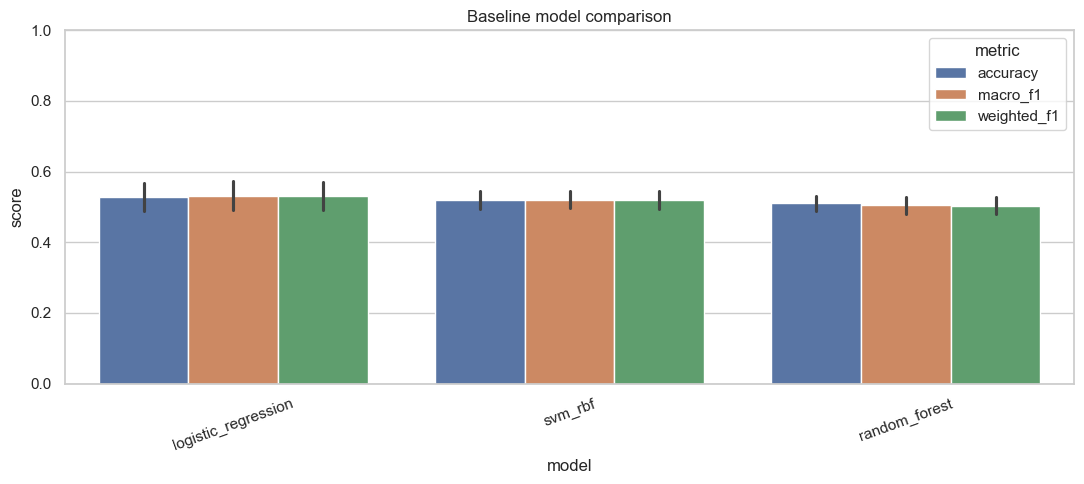

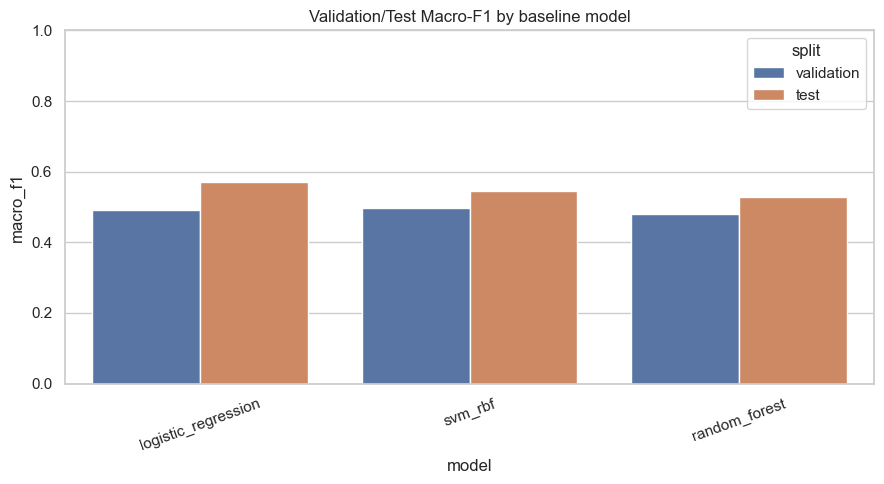

Saved figures: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\baseline_model_comparison.png D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\baseline_macro_f1_by_split.png


In [8]:
plot_df = metrics_df.melt(
    id_vars=["model", "split"],
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Baseline model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
comparison_path = FIGURE_DIR / "baseline_model_comparison.png"
plt.savefig(comparison_path, dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x="model", y="macro_f1", hue="split")
plt.title("Validation/Test Macro-F1 by baseline model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
macro_path = FIGURE_DIR / "baseline_macro_f1_by_split.png"
plt.savefig(macro_path, dpi=180)
plt.show()

print("Saved figures:", comparison_path, macro_path)

## 9. Confusion matrix

Confusion matrix giúp phân tích emotion nào bị nhầm. Đây là phần rất quan trọng trong báo cáo SER.

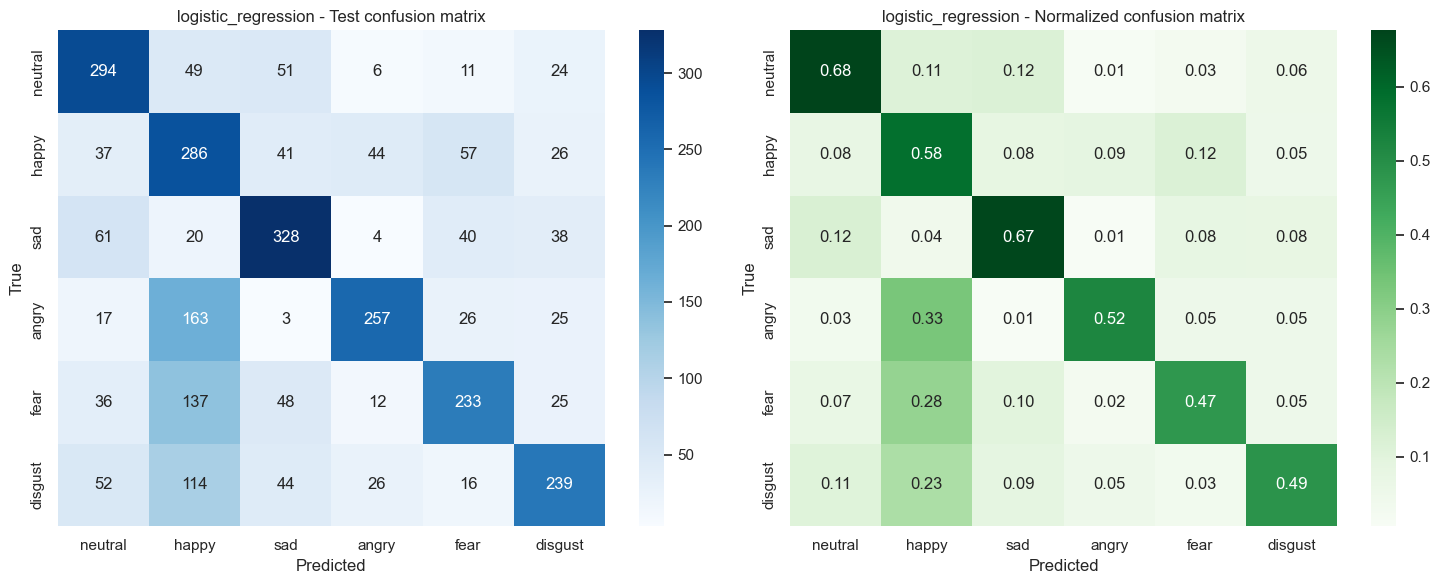

Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\confusion_matrix_logistic_regression_test.png


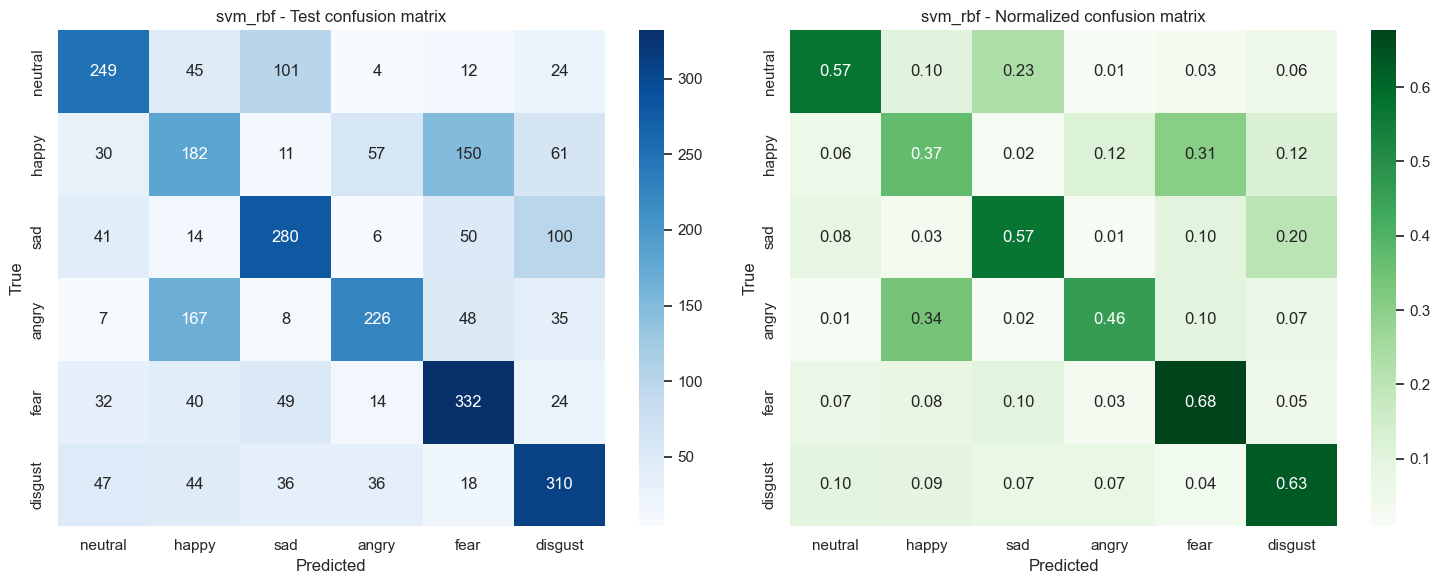

Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\confusion_matrix_svm_rbf_test.png


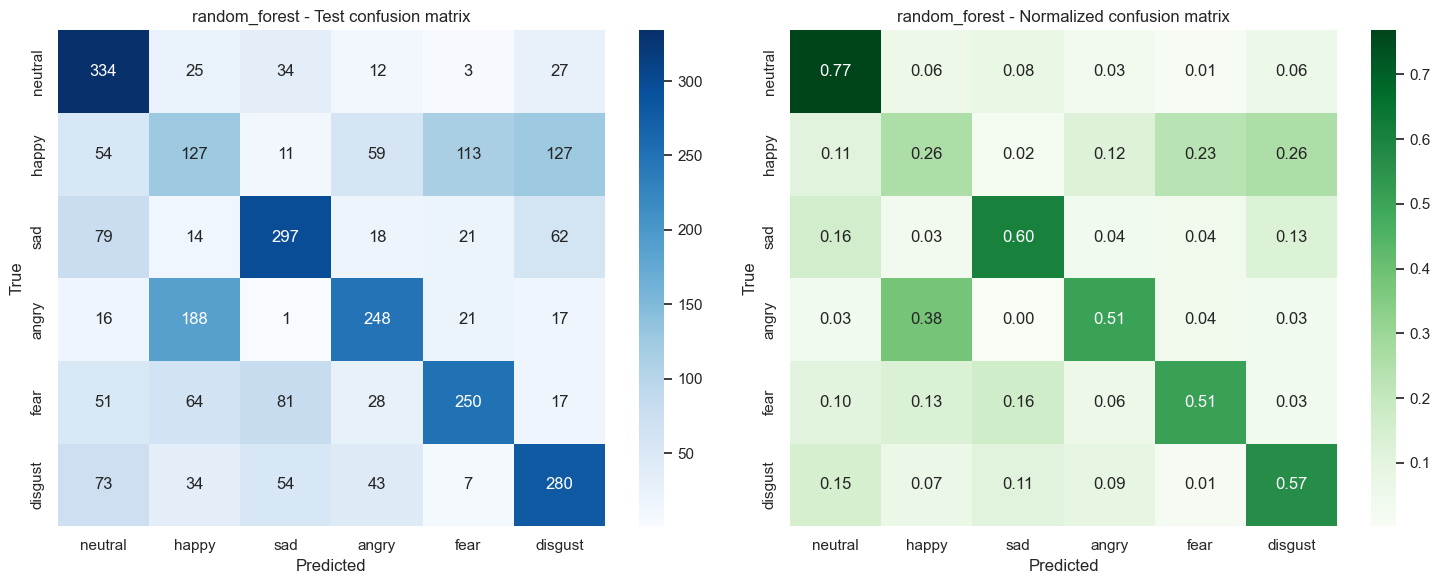

Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\confusion_matrix_random_forest_test.png


In [9]:
for model_name in models:
    pred_df = prediction_cache[(model_name, "test")]
    cm = confusion_matrix(pred_df["y_true"], pred_df["y_pred"], labels=label_order)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_order, yticklabels=label_order, ax=axes[0])
    axes[0].set_title(f"{model_name} - Test confusion matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=label_order, yticklabels=label_order, ax=axes[1])
    axes[1].set_title(f"{model_name} - Normalized confusion matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    out_path = FIGURE_DIR / f"confusion_matrix_{model_name}_test.png"
    plt.savefig(out_path, dpi=180)
    plt.show()
    print("Saved:", out_path)

## 10. Per-dataset performance

Phân tích theo dataset giúp trả lời câu hỏi: model học tốt trên dataset nào, generalization có ổn không, TESS có làm kết quả bị lệch không.

,model,dataset,n_samples,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
2,logistic_regression,TESS,1200,0.665833,0.678132,0.678132,0.789949,0.665833
0,logistic_regression,CREMA-D,1470,0.493878,0.495187,0.496331,0.504406,0.494413
1,logistic_regression,RAVDESS,220,0.509091,0.483299,0.493144,0.517930,0.504167
8,random_forest,TESS,1200,0.629167,0.598743,0.598743,0.643592,0.629167
6,random_forest,CREMA-D,1470,0.472109,0.463510,0.464287,0.487847,0.474721
7,random_forest,RAVDESS,220,0.395455,0.364442,0.355615,0.471166,0.400000
3,svm_rbf,CREMA-D,1470,0.535374,0.536086,0.537431,0.542992,0.535362
5,svm_rbf,TESS,1200,0.565000,0.530962,0.530962,0.568178,0.565000
4,svm_rbf,RAVDESS,220,0.518182,0.504870,0.500767,0.542970,0.520833


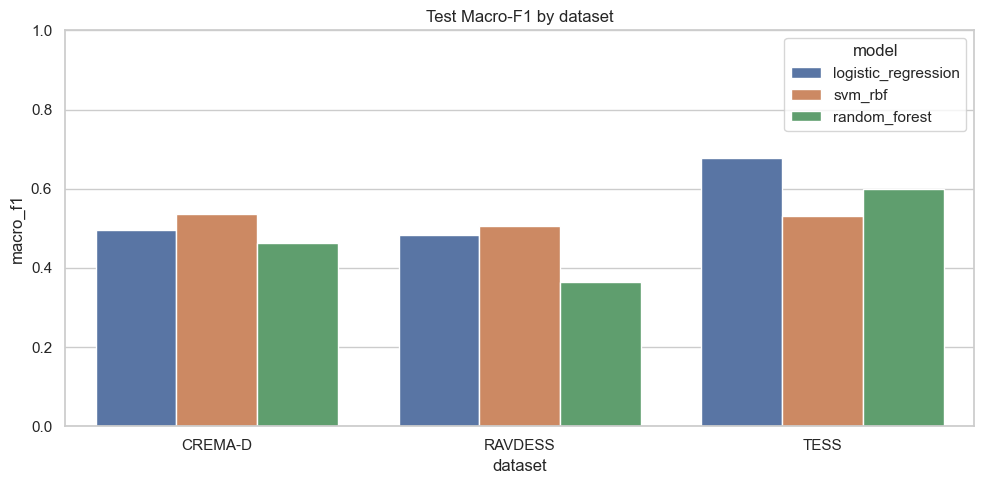

Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\per_dataset_macro_f1_test.png


In [10]:
per_dataset_rows = []

for model_name in models:
    pred_df = prediction_cache[(model_name, "test")]
    for dataset_name, part in pred_df.groupby("dataset"):
        per_dataset_rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "n_samples": len(part),
            **compute_metrics(part["y_true"], part["y_pred"]),
        })

per_dataset_df = pd.DataFrame(per_dataset_rows)
per_dataset_df.to_csv(REPORT_DIR / "per_dataset_metrics_test.csv", index=False)
display(per_dataset_df.sort_values(["model", "macro_f1"], ascending=[True, False]))

plt.figure(figsize=(10, 5))
sns.barplot(data=per_dataset_df, x="dataset", y="macro_f1", hue="model")
plt.title("Test Macro-F1 by dataset")
plt.ylim(0, 1)
plt.tight_layout()
dataset_path = FIGURE_DIR / "per_dataset_macro_f1_test.png"
plt.savefig(dataset_path, dpi=180)
plt.show()
print("Saved:", dataset_path)

## 11. Per-class F1

Biểu đồ F1 theo từng emotion cho biết emotion nào khó nhất. Phần này nên đưa vào report cùng confusion matrix.

,model,emotion,precision,recall,f1_score,support
0,logistic_regression,neutral,0.591549,0.675862,0.630901,435.0
1,logistic_regression,happy,0.371912,0.582485,0.453968,491.0
2,logistic_regression,sad,0.636893,0.668024,0.652087,491.0
3,logistic_regression,angry,0.736390,0.523422,0.611905,491.0
4,logistic_regression,fear,0.608355,0.474542,0.533181,491.0
5,logistic_regression,disgust,0.633952,0.486762,0.550691,491.0
6,svm_rbf,neutral,0.613300,0.572414,0.592152,435.0
7,svm_rbf,happy,0.369919,0.370672,0.370295,491.0
8,svm_rbf,sad,0.577320,0.570265,0.573770,491.0
9,svm_rbf,angry,0.658892,0.460285,0.541966,491.0


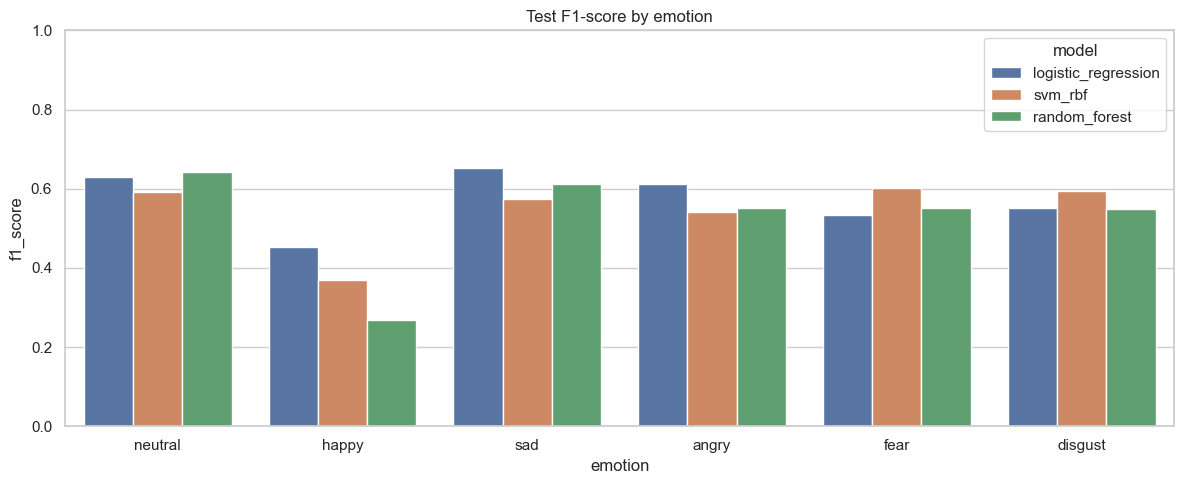

Saved: D:\UTE\Speech Programming\Speech Project\04_train_baseline_mfcc\outputs\figures\per_class_f1_test.png


In [11]:
per_class_rows = []

for model_name in models:
    report_path = REPORT_DIR / f"classification_report_{model_name}_test.csv"
    report_df = pd.read_csv(report_path, index_col=0)
    for emotion in label_order:
        if emotion in report_df.index:
            per_class_rows.append({
                "model": model_name,
                "emotion": emotion,
                "precision": report_df.loc[emotion, "precision"],
                "recall": report_df.loc[emotion, "recall"],
                "f1_score": report_df.loc[emotion, "f1-score"],
                "support": report_df.loc[emotion, "support"],
            })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(REPORT_DIR / "per_class_metrics_test.csv", index=False)
display(per_class_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=per_class_df, x="emotion", y="f1_score", hue="model", order=label_order)
plt.title("Test F1-score by emotion")
plt.ylim(0, 1)
plt.tight_layout()
class_path = FIGURE_DIR / "per_class_f1_test.png"
plt.savefig(class_path, dpi=180)
plt.show()
print("Saved:", class_path)

## 12. Error analysis nhanh

Cell này hiển thị một số mẫu dự đoán sai của model tốt nhất. Khi viết báo cáo, có thể dùng phần này để phân tích limitation.

In [12]:
best_pred_df = prediction_cache[(best_model_name, "test")]
errors = best_pred_df[~best_pred_df["correct"]].copy()

print("Best model:", best_model_name)
print("Test errors:", len(errors), "/", len(best_pred_df))

display(
    errors[["sample_id", "dataset", "speaker_id", "y_true", "y_pred"]]
    .head(30)
)

error_table = pd.crosstab(errors["y_true"], errors["y_pred"]).reindex(index=label_order, columns=label_order, fill_value=0)
display(error_table)
error_table.to_csv(REPORT_DIR / f"error_crosstab_{best_model_name}_test.csv")

Best model: svm_rbf
Test errors: 1311 / 2890


,sample_id,dataset,speaker_id,y_true,y_pred
0,s000132,RAVDESS,ravdess_04,neutral,fear
1,s000133,RAVDESS,ravdess_04,neutral,happy
2,s000134,RAVDESS,ravdess_04,neutral,happy
3,s000135,RAVDESS,ravdess_04,neutral,happy
5,s000137,RAVDESS,ravdess_04,happy,angry
10,s000142,RAVDESS,ravdess_04,happy,angry
11,s000143,RAVDESS,ravdess_04,happy,fear
12,s000144,RAVDESS,ravdess_04,sad,fear
13,s000145,RAVDESS,ravdess_04,sad,angry
14,s000146,RAVDESS,ravdess_04,sad,angry


y_pred,neutral,happy,sad,angry,fear,disgust
y_true,,,,,,
neutral,0,45,101,4,12,24
happy,30,0,11,57,150,61
sad,41,14,0,6,50,100
angry,7,167,8,0,48,35
fear,32,40,49,14,0,24
disgust,47,44,36,36,18,0


## 13. Lưu summary cho report

Cell này tạo một file JSON tóm tắt kết quả quan trọng nhất để dùng trong report/slide.

In [13]:
test_best = metrics_df[(metrics_df["model"] == best_model_name) & (metrics_df["split"] == "test")].iloc[0].to_dict()
val_best = metrics_df[(metrics_df["model"] == best_model_name) & (metrics_df["split"] == "validation")].iloc[0].to_dict()

summary = {
    "best_model": best_model_name,
    "validation": val_best,
    "test": test_best,
    "n_train": int(len(y_train)),
    "n_validation": int(len(y_val)),
    "n_test": int(len(y_test)),
    "labels": label_order,
    "feature_dim": int(X.shape[1]),
    "models_trained": list(models.keys()),
}

summary_path = REPORT_DIR / "baseline_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("Saved:", summary_path)

{
  "best_model": "svm_rbf",
  "validation": {
    "model": "svm_rbf",
    "split": "validation",
    "n_samples": 945,
    "accuracy": 0.49523809523809526,
    "macro_f1": 0.4962375398265997,
    "weighted_f1": 0.4952050666582334,
    "macro_precision": 0.5026769917806436,
    "macro_recall": 0.4967078189300411,
    "train_time_sec": 2.780898399883881,
    "inference_time_sec": 0.7169020001310855,
    "inference_ms_per_sample": 0.7586264551651699
  },
  "test": {
    "model": "svm_rbf",
    "split": "test",
    "n_samples": 2890,
    "accuracy": 0.5463667820069205,
    "macro_f1": 0.5457622784692987,
    "weighted_f1": 0.5448633734200247,
    "macro_precision": 0.5538766649653594,
    "macro_recall": 0.5468619050963316,
    "train_time_sec": 2.780898399883881,
    "inference_time_sec": 2.183536499971524,
    "inference_ms_per_sample": 0.755548961927863
  },
  "n_train": 7062,
  "n_validation": 945,
  "n_test": 2890,
  "labels": [
    "neutral",
    "happy",
    "sad",
    "angry",
   

## 14. Đóng gói output để tải về

Kaggle thường hỗ trợ tải `.zip` tốt nhất. Nếu môi trường có lệnh `rar`, cell này sẽ tạo thêm `.rar`; nếu không có, notebook sẽ tự fallback sang `.zip`.

Output nằm trong:

- Kaggle: `/kaggle/working/baseline_mfcc_results.zip`
- Local: folder project hiện tại

In [14]:
archive_base = PROJECT_ROOT / "baseline_mfcc_results"
zip_path = archive_base.with_suffix(".zip")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(archive_base),
    format="zip",
    root_dir=str(OUTPUT_DIR.parent),
    base_dir=OUTPUT_DIR.name,
)
print("Created ZIP:", zip_path)

rar_exe = shutil.which("rar")
rar_path = archive_base.with_suffix(".rar")

if rar_exe:
    if rar_path.exists():
        rar_path.unlink()
    try:
        subprocess.run(
            [rar_exe, "a", "-r", str(rar_path), OUTPUT_DIR.name],
            cwd=str(OUTPUT_DIR.parent),
            check=True,
        )
        print("Created RAR:", rar_path)
    except Exception as exc:
        print("RAR creation failed, ZIP is still available:", exc)
else:
    print("RAR executable not found. ZIP package is available instead.")

print("Package size MB:", round(zip_path.stat().st_size / 1024 / 1024, 2))

Created ZIP: D:\UTE\Speech Programming\Speech Project\baseline_mfcc_results.zip
RAR executable not found. ZIP package is available instead.
Package size MB: 37.09


## 15. Checklist sau khi chạy

Sau khi chạy notebook, kiểm tra các file sau:

- `models/best_baseline_model.pkl`
- `models/logistic_regression.pkl`
- `models/svm_rbf.pkl`
- `models/random_forest.pkl`
- `reports/metrics_summary.csv`
- `reports/per_dataset_metrics_test.csv`
- `reports/per_class_metrics_test.csv`
- `figures/baseline_model_comparison.png`
- `figures/confusion_matrix_*_test.png`
- `baseline_mfcc_results.zip`

Nếu SVM RBF quá chậm trên Kaggle CPU, tắt `RUN_RBF_SVM` rồi chạy lại để có Logistic Regression và Random Forest trước.